# Article - Issue Statement Figure

This first figure of the article has as objective to demonstrate the issues in the Raster product that are possible to be stated visually. 

## Imports

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from swot_toolkit.analysis import plot_inner_swath_analysis
from swot_toolkit.opera import plot_opera_array
from swot_toolkit.pipe2 import open_output_dir
from swot_toolkit.pipe4 import create_swot_mosaic, open_datasets, plot_ref_mask, plot_s2_rgb


## Figure 1

In [3]:
REGION = "Rio_Branco"
OUTPUT_DIR = "/data/swot/output"
DATE = "2025-09-07"

In [4]:
base_dir, aoi, s2_id = open_output_dir(REGION, DATE)
datasets = open_datasets(REGION, DATE)

The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']


In [8]:
swot_mask, patches, no_data_masks = create_swot_mosaic(
    REGION,
    DATE,
    dst_crs=datasets["ref_mask"].rio.crs,
    exclude_flags=None,
    exclude_no_data=False,
)

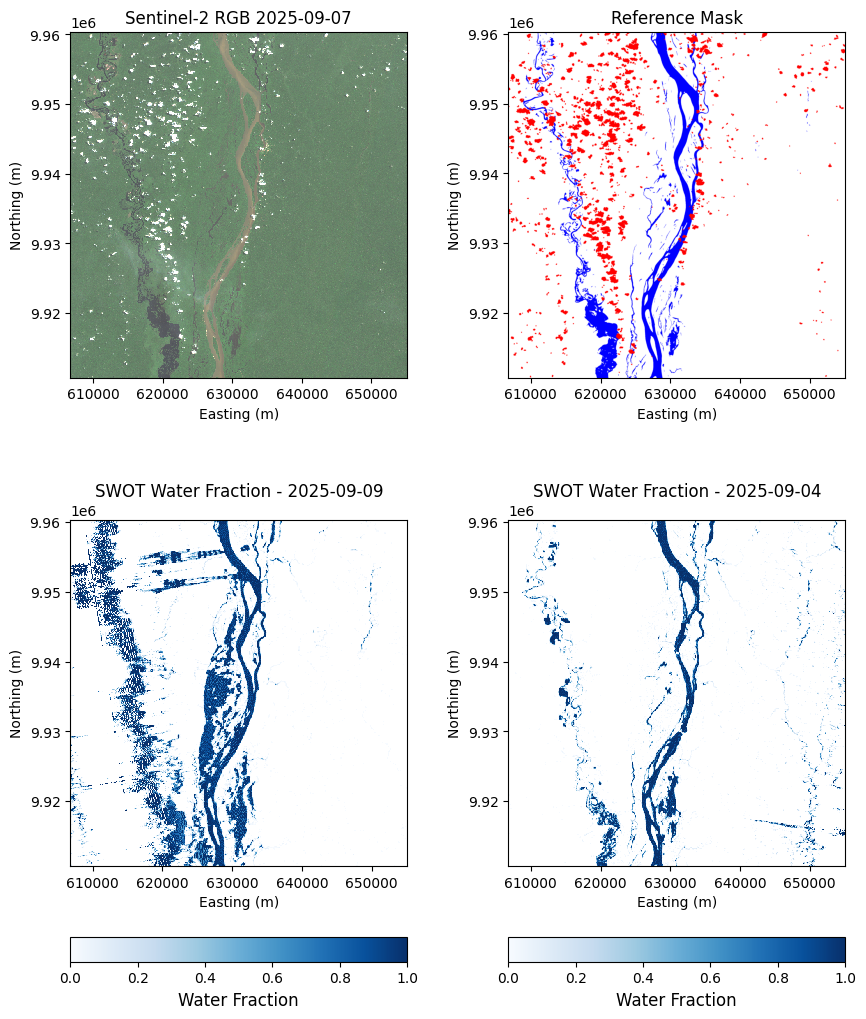

In [ ]:
fig = plt.figure(figsize=(10, 13))

# Create a grid layout
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.05], hspace=0.0, wspace=0.3)

# Top row
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Bottom row
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Colorbar axis
cbar_ax1 = fig.add_subplot(gs[2, 0])
cbar_ax2 = fig.add_subplot(gs[2, 1])

# Plot data
plot_s2_rgb(datasets["s2_img"], ax=ax1)
ax1.set_aspect("equal")
ax1.set_title(f"Sentinel-2 RGB {DATE}")
ax1.set_xlabel("Easting (m)")
ax1.set_ylabel("Northing (m)")

plot_ref_mask(datasets["ref_mask"], down_factor=2, ax=ax2, add_colorbar=False)
ax2.set_aspect("equal")
ax2.set_title("Reference Mask")
ax2.set_xlabel("Easting (m)")
ax2.set_ylabel("Northing (m)")
# Plot SWOT patches
for i, patch in enumerate(patches[::-1]):
    ax = ax3 if i == 0 else ax4
    patch = patch.where(patch["water_frac"] > 0)
    im = patch["water_frac"].plot(ax=ax, cmap="Blues", vmin=0, vmax=1, add_colorbar=False)
    ax.set_aspect("equal")
    ax.set_title(f"SWOT Water Fraction - {patch.attrs['time_coverage_start'][:10]}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

# Add shared colorbar
cbar1 = plt.colorbar(im, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Water Fraction", fontsize=12)

cbar2 = plt.colorbar(im, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Water Fraction", fontsize=12)

## Figure 2

In [19]:
import earthaccess
import geopandas as gpd
import rioxarray as xrio

from swot_toolkit.analysis import plot_footprint, plot_nadir_line, plot_water_fraction


In [20]:
# First, open the output directory for this region and date
base_dir = Path(OUTPUT_DIR) / REGION
mosaic_df = pd.read_parquet(base_dir / "dfs/swot_raster_results.parquet")
mosaic_items = mosaic_df.loc[DATE]

In [21]:
# Get the files
mosaic_files = earthaccess.download(
    mosaic_items["url"].to_list(),
    local_path="/data/swot/download",
    pqdm_kwargs={"disable": True},
)

In [22]:
aoi_gdf = gpd.GeoDataFrame(geometry=[aoi], crs="EPSG:4326")


In [27]:
mosaic_files

['/data/swot/download/SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_038_117_077F_20250904T091500_20250904T091522_PID0_01.nc',
 '/data/swot/download/SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_038_270_078F_20250909T202640_20250909T202701_PID0_01.nc']

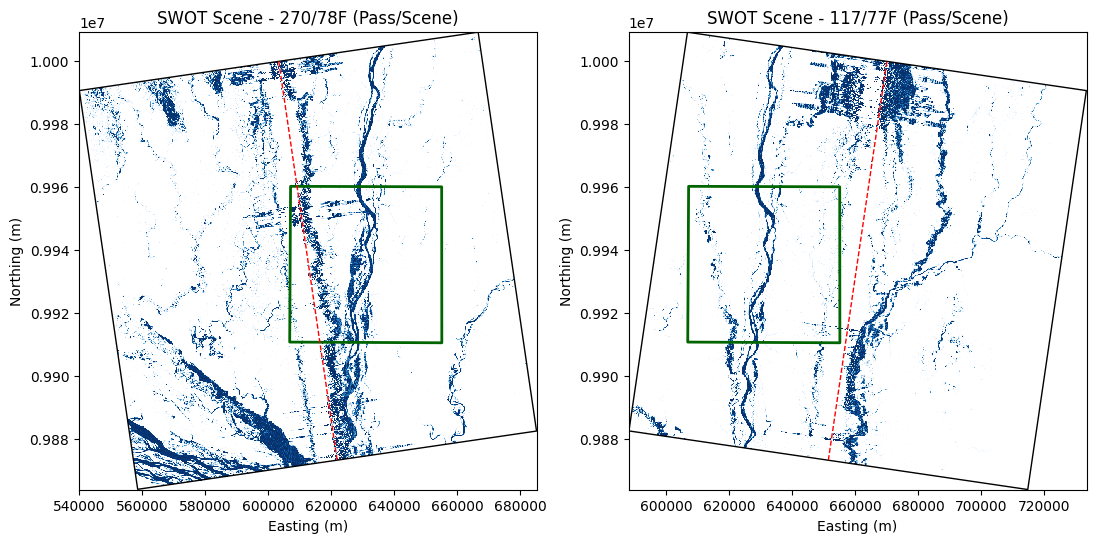

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6))

for ax, file in zip(axs.reshape(-1), mosaic_files[::-1], strict=True):
    ds = xrio.open_rasterio(file, mask_and_scale=True).squeeze()

    water_frac = ds["water_frac"].sel(x=slice(None, None, 2), y=slice(None, None, 2)).squeeze()
    water_frac.plot.imshow(ax=ax, vmin=0, vmax=1, add_colorbar=False, cmap="Blues")

    nadir_handle = plot_nadir_line(ds, ax)
    footprint_handle = plot_footprint(ds, ax)

    aoi_gdf.to_crs(ds.rio.crs).plot(ax=ax, facecolor="none", edgecolor="darkgreen", linewidth=2)

    title = "SWOT Scene - "
    title += str(ds.attrs["pass_number"]) + "/" + str(ds.attrs["scene_number"])
    title += "F (Pass/Scene)"
    ax.set_title(title)
    ax.set_ylabel("Northing (m)")
    ax.set_xlabel("Easting (m)")


In [28]:
# First, open the output directory for this region and date
base_dir = Path(OUTPUT_DIR) / REGION
mosaic_df = pd.read_parquet(base_dir / "dfs/swot_raster_results.parquet")
mosaic_dates = mosaic_df.index.get_level_values("mosaic_date").unique()
mosaic_dates

DatetimeIndex(['2024-01-11', '2024-01-31', '2024-02-21', '2024-03-13',
               '2024-04-03', '2024-04-24', '2024-06-05', '2024-06-25',
               '2024-07-16', '2024-08-06', '2024-08-27', '2024-09-17',
               '2024-10-08', '2024-10-29', '2024-11-19', '2025-01-20',
               '2025-02-10', '2025-03-03', '2025-03-24', '2025-04-14',
               '2025-05-04', '2025-05-25', '2025-06-15', '2025-07-06',
               '2025-07-27', '2025-08-17', '2025-09-07'],
              dtype='datetime64[ns]', name='mosaic_date', freq=None)

In [29]:
figs = plot_inner_swath_analysis(REGION, DATE)

/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_038_117_077F_20250904T091500_20250904T091522_PID0_01.nc
/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_038_270_078F_20250909T202640_20250909T202701_PID0_01.nc


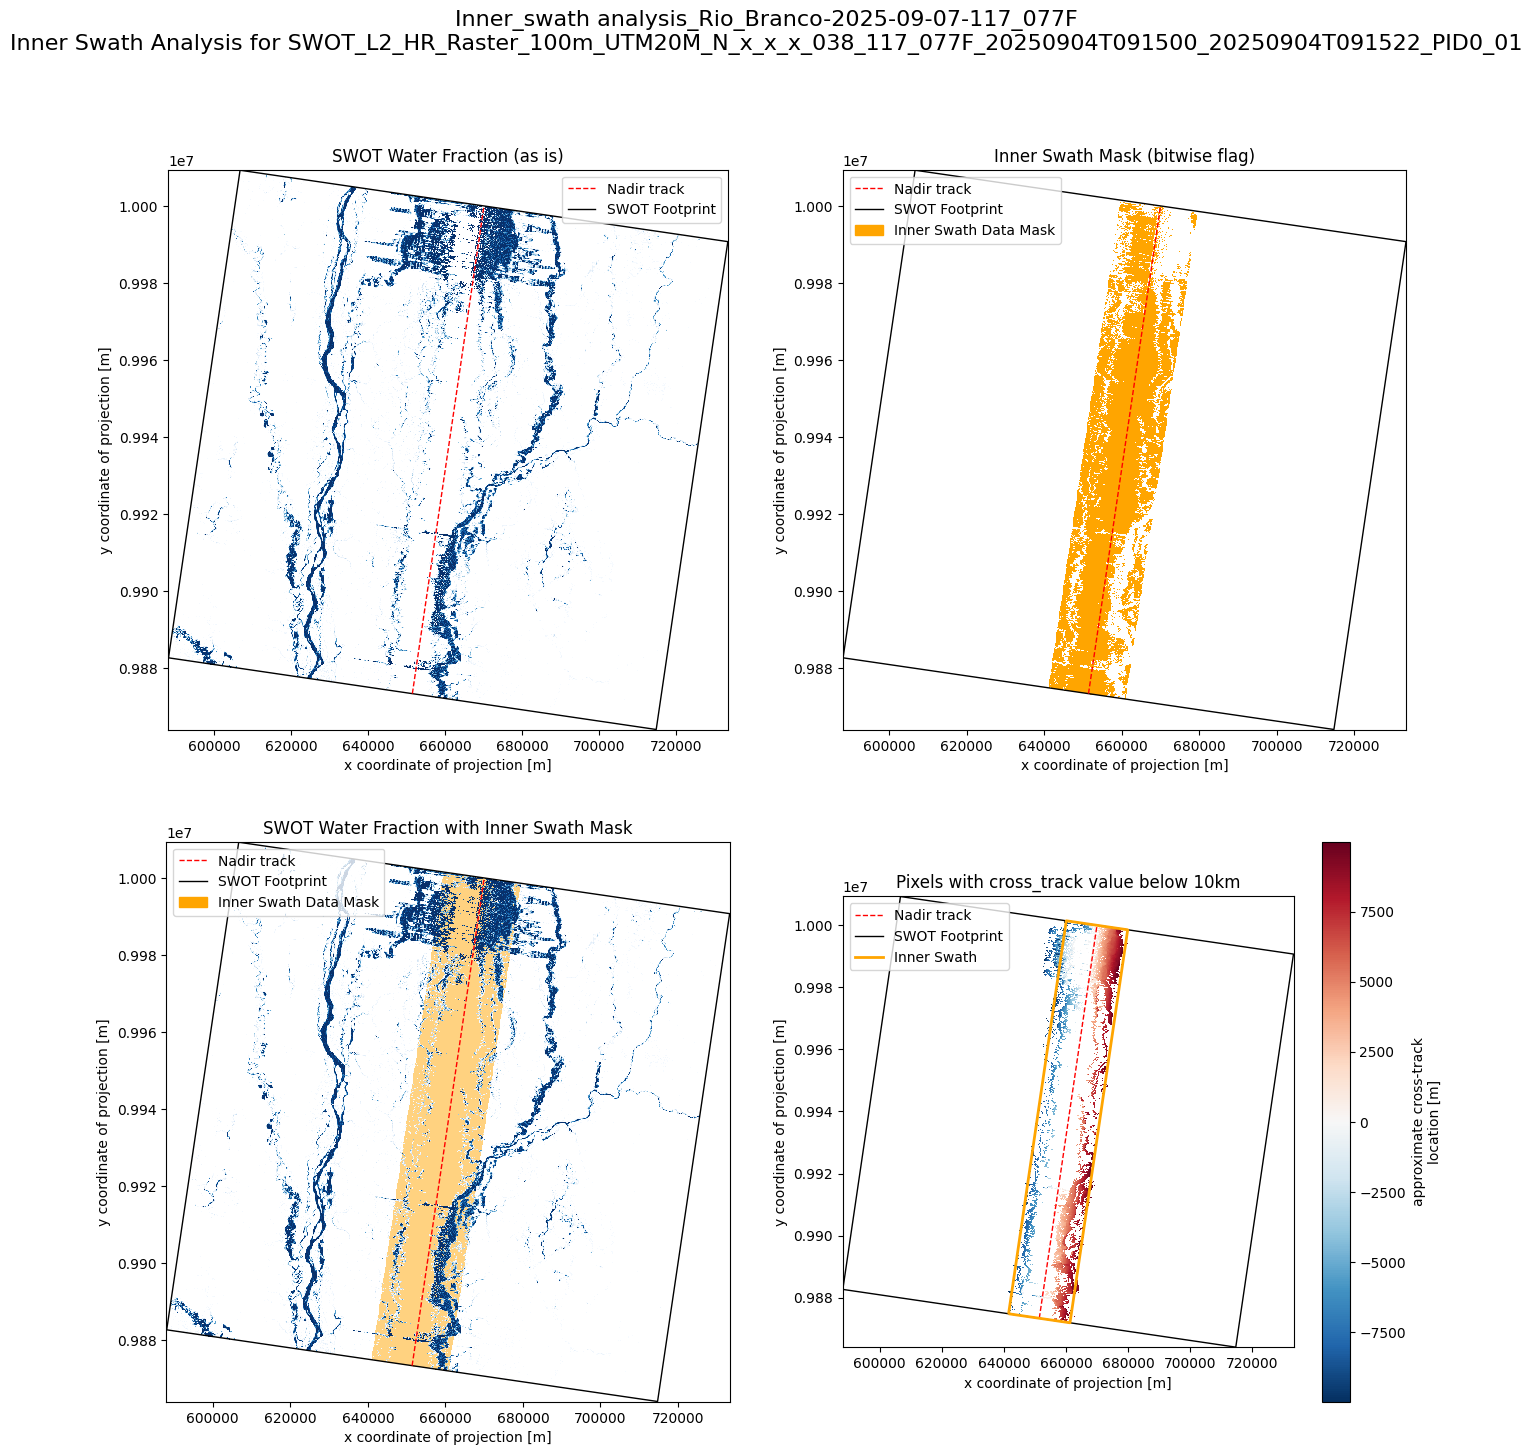

In [30]:
figs[0]

## Figure 3

In [35]:
import xarray as xr

In [39]:
averaged = xr.concat(patches, dim="idx").mean(dim="idx")

In [42]:
averaged = averaged.where(averaged["water_frac"] > 0)

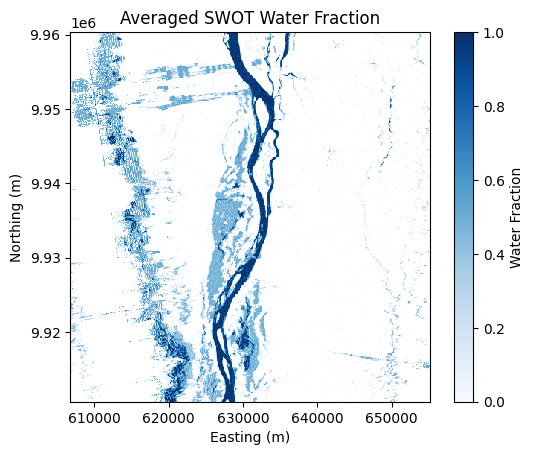

In [47]:
fig, ax = plt.subplots()
im = averaged["water_frac"].plot(cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_ylabel("Northing (m)")
ax.set_xlabel("Easting (m)")
ax.set_title("Averaged SWOT Water Fraction")
ax.set_aspect("equal")
im.colorbar.set_label("Water Fraction")

In [53]:
mosaic_item

,cycle_id,pass_id,tile_id,date_str,vers,datetime,date,native-id,url
tile_name,,,,,,,,,
117_077F,009,117,077F,20240108T072742,PIC0_01,2024-01-08 07:27:42,2024-01-08,SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_009_117_...,https://archive.swot.podaac.earthdata.nasa.gov...
270_078F,009,270,078F,20240113T183922,PIC0_01,2024-01-13 18:39:22,2024-01-13,SWOT_L2_HR_Raster_100m_UTM20M_N_x_x_x_009_270_...,https://archive.swot.podaac.earthdata.nasa.gov...


Text(0.5, 1.0, 'SWOT Footprints - scenes 077F and 078F')

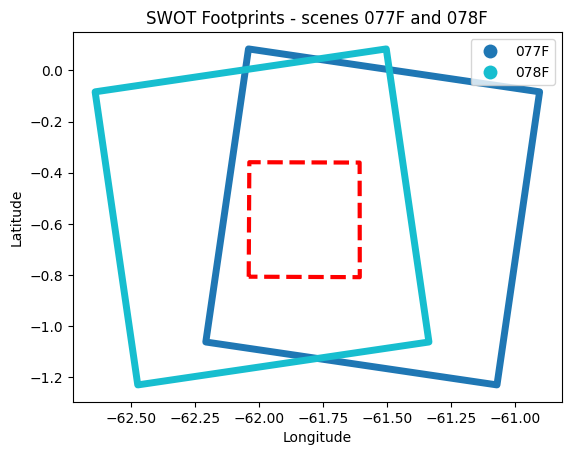

In [60]:
from swot_toolkit.plotting import plot_mosaic_footprints

mosaic_item = mosaic_df.loc["2024-01-11"]

fig, ax = plt.subplots()
plot_mosaic_footprints(mosaic_item, aoi=aoi, ax=ax)
ax.set_title("SWOT Footprints - scenes 077F and 078F")

## Figure 4

In [90]:
from matplotlib.colors import ListedColormap

from swot_toolkit.flags import mask_by_flags


In [64]:
REGION = "Rio_Madeira"
OUTPUT_DIR = "/data/swot/output"
DATE = "2025-07-21"

In [65]:
base_dir, aoi, s2_id = open_output_dir(REGION, DATE)
datasets = open_datasets(REGION, DATE)

The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']


In [66]:
swot_mask, patches, no_data_masks = create_swot_mosaic(
    REGION,
    DATE,
    dst_crs=datasets["ref_mask"].rio.crs,
    exclude_flags=None,
    exclude_no_data=False,
)

In [84]:
patch = patches[0]
scene_date = patch.attrs["time_granule_start"][:10]
scene_date

'2025-07-23'

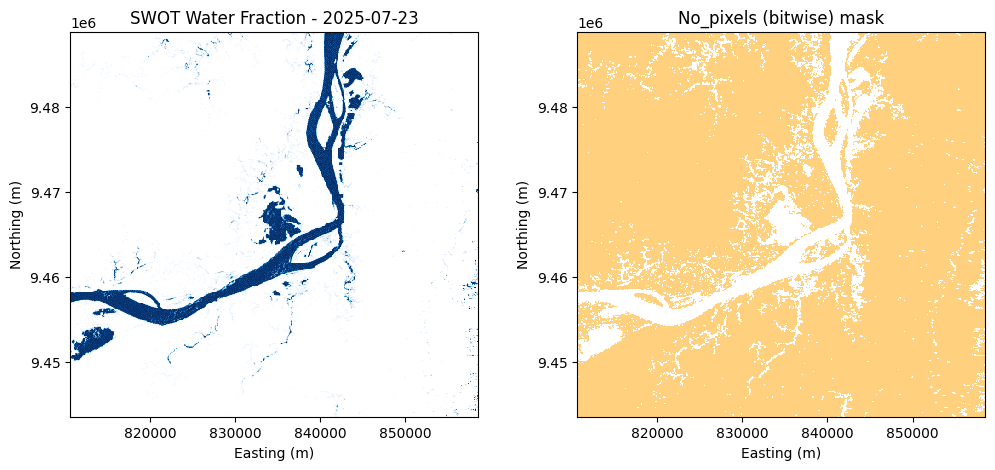

In [97]:

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot the water fraction
water = patch.where(patch["water_frac"] > 0)["water_frac"]
water.plot(cmap="Blues", vmin=0, vmax=1, ax=axs[0], add_colorbar=False)
axs[0].set_title(f"SWOT Water Fraction - {scene_date}")
axs[0].set_ylabel("Northing (m)")
axs[0].set_xlabel("Easting (m)")
axs[0].set_aspect("equal")

# Plot the no_pixels mask
mask_np = mask_by_flags(patch["water_area_qual_bitwise"], ["no_pixels"])
mask = patch["water_area_qual_bitwise"].copy()
mask.data = mask_np.astype("int")

custom_cmap = ListedColormap(["white", "orange"])
mask.plot(cmap=custom_cmap, vmin=0, vmax=1, add_colorbar=False, ax=axs[1], alpha=0.5)
axs[1].set_title("No_pixels (bitwise) mask")
axs[1].set_ylabel("Northing (m)")
axs[1].set_xlabel("Easting (m)")
axs[1].set_aspect("equal")


In [ ]:

axs[1].set_title("No Data Mask")
no_data = no_data_masks[0]
no_data.plot(ax=axs[1], cmap="gray", vmin=0, vmax=1)

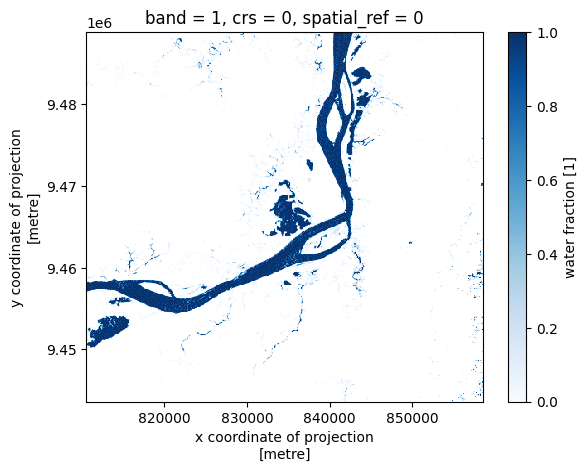

In [80]:
water = patch.where(patch["water_frac"] > 0)["water_frac"]

water.plot(cmap="Blues", vmin=0, vmax=1)

Output directory created at: /data/swot/output_article/Rio_Branco
Searching for Sentinel-2 scenes intersecting the AOI...
S2 tile not provided. Guessing the best tile...
Tile 20MNE has 5631010 null values.
Tile 20MPE has 4834296 null values.
Best tile is 20MPE.
Assessing clouds in Sentinel-2 scenes...


  0%|          | 0/280 [00:00<?, ?it/s]

Searching for OPERA satellite data intersecting the AOI...
Found 222 OPERA satellite overpasses intersecting the AOI.
Searching for SWOT Raster_100 data intersecting the AOI...
Creating SWOT mosaics...


  0%|          | 0/27 [00:00<?, ?it/s]

Saving dataframes to /data/swot/output_article/Rio_Branco/dfs...


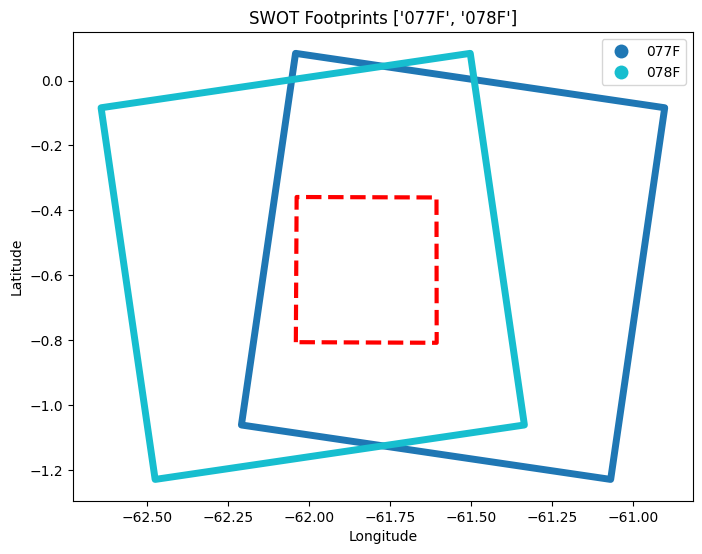

In [6]:
aoi_path = Path("/data/swot/AOIs/") / f"{REGION}.kml"
output_dir = prepare_aoi_dataframes(aoi_path, DATE_RANGE, OUTPUT_DIR)

## Analyze results

In [3]:
from pathlib import Path

import pandas as pd

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.pipe1 import generate_s2_figs_from_mosaic

In [5]:
output_dir = Path(OUTPUT_DIR) / REGION
output_dir

PosixPath('/data/swot/output_article/Rio_Branco')

In [11]:
# Open the matches between S2 and SWOT
matches = pd.read_parquet(output_dir / "dfs/swot_s2_matches.parquet")
matches.sort_values("valid_pxls", ascending=False).iloc[:10]


,date,datetime,tile,valid_pxls,OPERA
swot_mosaic_date,,,,,
2024-04-03,2024-03-30,2024-03-30 14:27:11.024,20MPE,0.986592,S2A
2024-02-21,2024-02-19,2024-02-19 14:27:11.024,20MPE,0.985682,S2A
2024-08-27,2024-08-22,2024-08-22 14:27:09.024,20MPE,0.959455,S2B
2025-09-07,2025-09-11,2025-09-11 14:27:31.025,20MPE,0.935522,S2C
2025-09-17,2025-09-21,2025-09-21 14:27:31.025,20MPE,0.933603,S2C
2025-04-14,2025-04-14,2025-04-14 14:28:11.025,20MPE,0.926655,S2C
2024-01-31,2024-01-30,2024-01-30 14:27:11.024,20MPE,0.904537,S2A
2024-02-21,2024-02-24,2024-02-24 14:27:09.024,20MPE,0.895677,S2B
2025-07-27,2025-07-23,2025-07-23 14:28:11.025,20MPE,0.835962,S2C


### Choose a mosaic date to check the S2 items (figs generated in output dir)

In [6]:
swot_df = pd.read_parquet(output_dir / "dfs/swot_raster_results.parquet")
swot_df

cycle_id pass_id tile_id         date_str     vers  \
mosaic_date tile_name                                                      
2024-01-11  117_077F       009     117    077F  20240108T072742  PIC0_01   
            270_078F       009     270    078F  20240113T183922  PIC0_01   
2024-01-31  117_077F       010     117    077F  20240129T041248  PIC0_01   
            270_078F       010     270    078F  20240203T152428  PIC0_01   
2024-02-21  117_077F       011     117    077F  20240219T005753  PIC0_01   
            270_078F       011     270    078F  20240224T120933  PIC0_01   
2024-03-13  117_077F       012     117    077F  20240310T214256  PIC0_01   
            270_078F       012     270    078F  20240316T085435  PIC0_01   
2024-04-03  117_077F       013     117    077F  20240331T182801  PIC0_01   
            270_078F       013     270    078F  20240406T053940  PIC0_01   
2024-04-24  117_077F       014     117    077F  20240421T151307  PIC0_02   
            270_078F       014     270    078F  20240427T022446  PIC0_01   
2024-06-05  117_077F       016     117    077F  20240602T084316  PIC0_01   
            270_078F       016     270    078F  20240607T195455  PIC0_01   
2024-06-25  117_077F       017     117    077F  20240623T052820  PIC0_01   
            270_078F       017     270    078F  20240628T163959  PIC0_01   
2024-07-16  117_077F       018     117    077F  20240714T021324  PIC0_01   
            270_078F       018     270    078F  20240719T132504  PIC0_03   
2024-08-06  117_077F       019     117    077F  20240803T225828  PIC0_01   
            270_078F       019     270    078F  20240809T101009  PIC0_01   
2024-08-27  117_077F       020     117    077F  20240824T194332  PIC0_02   
            270_078F       020     270    078F  20240830T065513  PIC0_01   
2024-09-17  117_077F       021     117    077F  20240914T162838  PIC0_01   
            270_078F       021     270    078F  20240920T034020  PIC0_01   
2024-10-08  117_077F       022     117    077F  20241005T131347  PIC0_01   
            270_078F       022     270    078F  20241011T002525  PIC0_03   
2024-10-29  117_077F       023     117    077F  20241026T095850  PIC2_01   
            270_078F       023     270    078F  20241031T211029  PIC2_02   
2024-11-19  117_077F       024     117    077F  20241116T064354  PIC2_01   
            270_078F       024     270    078F  20241121T175535  PIC2_01   
2025-01-20  117_077F       027     117    077F  20250117T205908  PIC2_01   
            270_078F       027     270    078F  20250123T081048  PIC2_01   
2025-02-10  117_077F       028     117    077F  20250207T174411  PIC2_01   
            270_078F       028     270    078F  20250213T045551  PIC2_01   
2025-03-03  117_077F       029     117    077F  20250228T142917  PIC2_01   
            270_078F       029     270    078F  20250306T014056  PIC2_01   
2025-03-24  117_077F       030     117    077F  20250321T111422  PIC2_01   
            270_078F       030     270    078F  20250326T222601  PIC2_01   
2025-04-14  117_077F       031     117    077F  20250411T075926  PIC2_01   
            270_078F       031     270    078F  20250416T191106  PIC2_01   
2025-05-15  117_077F       033     117    077F  20250523T012936  PID0_01   
            270_078F       032     270    078F  20250507T155609  PID0_03   
2025-06-15  117_077F       034     117    077F  20250612T221440  PID0_01   
            270_078F       034     270    078F  20250618T092619  PID0_01   
2025-07-06  117_077F       035     117    077F  20250703T185947  PID0_01   
            270_078F       035     270    078F  20250709T061127  PID0_01   
2025-07-27  117_077F       036     117    077F  20250724T154452  PID0_01   
            270_078F       036     270    078F  20250730T025631  PID0_01   
2025-08-17  117_077F       037     117    077F  20250814T122956  PID0_01   
            270_078F       037     270    078F  20250819T234136  PID0_01   
2025-09-07  117_077F       038     117    077F  20250904T091500  PID0_